<a href="https://colab.research.google.com/github/Debnath-Goutam/MS-DACS/blob/master/MSDACS_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mounts and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics
!pip install torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 7.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os, random
from glob import glob
import pickle
import torch, torchvision
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import seaborn as sns

from torchvision.transforms import functional as F
import torch.nn.functional as nnF
from multiprocessing.pool import ThreadPool
from sklearn.cluster import KMeans
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
from ultralytics import YOLO
from collections import defaultdict
import cv2

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


# Raw Data Load

In [4]:
def collect_img_paths(root, modality):
    paths = []
    set_dirs = sorted(glob(os.path.join(root, 'set*')))
    for s in set_dirs:
        V_dirs = sorted(glob(os.path.join(s, 'V*')))
        if V_dirs:
            for v in V_dirs:
                img_dir = os.path.join(v, modality)
                imgs = sorted(glob(os.path.join(img_dir, '*.jpg')))
                paths.extend(imgs)
        else:
            img_dir = os.path.join(s, modality)
            imgs = sorted(glob(os.path.join(img_dir, '*.jpg')))
            paths.extend(imgs)
    return paths

In [5]:
def make_paired_dataset(root, img_size=(640, 640), batch_size=32):
    visible_paths_full = collect_img_paths(root, 'visible')
    lwir_paths_full = collect_img_paths(root, 'lwir')

    # Create dictionaries mapping a unique key (without modality) to the full path
    visible_map = {}
    for p in visible_paths_full:
        key = p.replace('/visible/', '/') # Remove modality part for common key
        visible_map[key] = p

    lwir_map = {}
    for p in lwir_paths_full:
        key = p.replace('/lwir/', '/') # Remove modality part for common key
        lwir_map[key] = p

    # Find common keys (images present in both modalities)
    common_keys = sorted(list(set(visible_map.keys()).intersection(set(lwir_map.keys()))))

    # Reconstruct the paired lists using only common keys
    visible_paths_filtered = [visible_map[key] for key in common_keys]
    lwir_paths_filtered = [lwir_map[key] for key in common_keys]

    # Assert that the filtered lists have the same length
    if len(visible_paths_filtered) != len(lwir_paths_filtered):
        raise ValueError("Filtered visible and LWIR paths do not have the same length.")

    paths = tf.data.Dataset.from_tensor_slices((visible_paths_filtered, lwir_paths_filtered))

    def _load_pairs(vis_path, ir_path):
        vis = tf.io.read_file(vis_path)
        vis = tf.image.decode_jpeg(vis, channels=3)
        vis = tf.image.resize(vis, img_size)
        vis = tf.cast(vis, tf.uint8)

        ir = tf.io.read_file(ir_path)
        ir = tf.image.decode_jpeg(ir, channels=1)
        ir = tf.image.resize(ir, img_size)
        ir = tf.repeat(ir, repeats=3, axis=-1)
        ir = tf.cast(ir, tf.uint8)

        return (vis, ir), vis_path

    dataset = paths.map(_load_pairs, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size=batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [6]:
root = '/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset'

#visible_dataset = make_dataset(root, modality='visible')
#ir_dataset = make_dataset(root, modality='lwir')

paired_dataset = make_paired_dataset(root)

for (vis_batch, ir_batch), paths in paired_dataset.take(1):
    print('Visible:', vis_batch.shape)
    print('IR:', ir_batch.shape)
    print('First path:', paths[0].numpy().decode())

Visible: (32, 640, 640, 3)
IR: (32, 640, 640, 3)
First path: /content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set00/V000/visible/I00000.jpg


In [7]:
visible_paths = collect_img_paths(root, 'visible')
lwir_paths = collect_img_paths(root, 'lwir')

print(f"Number of visible image paths: {len(visible_paths)}")
print(f"Number of LWIR image paths: {len(lwir_paths)}")

# Convert to sets for easier comparison
visible_set = set(visible_paths)
lwir_set = set(lwir_paths)

# Find paths that are in visible but not in lwir
missing_in_lwir = visible_set - lwir_set
print(f"\nPaths in visible but not in lwir: {len(missing_in_lwir)} files")
if missing_in_lwir:
    for path in list(missing_in_lwir)[:5]: # Print first 5 discrepancies
        print(path)

# Find paths that are in lwir but not in visible
missing_in_visible = lwir_set - visible_set
print(f"\nPaths in lwir but not in visible: {len(missing_in_visible)} files")
if missing_in_visible:
    for path in list(missing_in_visible)[:5]: # Print first 5 discrepancies
        print(path)


Number of visible image paths: 50185
Number of LWIR image paths: 50184

Paths in visible but not in lwir: 50185 files
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set01/V000/visible/I01412.jpg
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set04/V001/visible/I01598.jpg
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set00/V006/visible/I00268.jpg
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set01/V000/visible/I01250.jpg
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set00/V003/visible/I00451.jpg

Paths in lwir but not in visible: 50184 files
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set03/V001/lwir/I01729.jpg
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set05/lwir/I02770.jpg
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set01/V002/lwir/I00172.jpg
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set00/V003/lwir/I00436.jpg
/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset/set00/V000/lwir/I02237.jpg


In [8]:
len(paired_dataset)

1569

# Data Preprocessing

## Raw Data

In [9]:
def get_sequence_id(path):
  parts = path.split(os.sep)
  return os.path.join(parts[-3], parts[-2])

In [10]:
sequence_dict = defaultdict(list)

for rgb, ir in zip(visible_paths, lwir_paths):
  seq_id = get_sequence_id(rgb)
  sequence_dict[seq_id].append((rgb, ir))

In [11]:
all_sequences = list(sequence_dict.keys())
random.seed(50) # You can choose any integer here
random.shuffle(all_sequences)

split_idx = int(0.8 * len(all_sequences))

train_seqs = all_sequences[:split_idx]
test_seqs = all_sequences[split_idx:]

In [12]:
train_pairs = []
test_pairs = []

for seq in train_seqs:
  train_pairs.extend(sequence_dict[seq])

for seq in test_seqs:
  test_pairs.extend(sequence_dict[seq])

## Pipeline

In [13]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

yolo_model = YOLO(
    "yolov8n.pt"
)

yolo_model.model.to(device)

frcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True).to(device)

frcnn_model.eval()

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 206MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [14]:
for p in yolo_model.model.parameters():
    p.requires_grad=False

for p in frcnn_model.parameters():
    p.requires_grad=False

In [15]:
from re import VERBOSE
def detect_yolo(rgb_image, conf_thresh=0.3):
    global yolo_model

    if yolo_model is None:
        from ultralytics import YOLO
        yolo_model = YOLO("yolov8n.pt")

    results = yolo_model(rgb_image, verbose=False)[0]
    boxes = []

    for box in results.boxes:
        cls = int(box.cls.item())
        conf = float(box.conf.item())

        if cls == 0 and conf >= conf_thresh:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            boxes.append([x1, y1, x2, y2, conf])

    return boxes

In [16]:
def detect_frcnn(rgb_image, conf_thresh=0.5):

  try:

    img_tensor = F.to_tensor(rgb_image)
    img_tensor = img_tensor.to(device) # Move tensor to the correct device

    with torch.no_grad():
      outputs = frcnn_model([img_tensor])[0]

    boxes = []

    for i in range(len(outputs['boxes'])):
      label = int(outputs['labels'][i])
      score = float(outputs['scores'][i])

      if label == 1 and score >= conf_thresh:
        x1, y1, x2, y2 = map(int, outputs['boxes'][i].tolist())
        boxes.append([x1, y1, x2, y2, score])

    return boxes

  except Exception as e:
    print('F-RCNN Error', e)
    return []

In [17]:
def compute_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)

    interArea = inter_w * inter_h

    boxAArea = max(0, boxA[2] - boxA[0]) * \
               max(0, boxA[3] - boxA[1])

    boxBArea = max(0, boxB[2] - boxB[0]) * \
               max(0, boxB[3] - boxB[1])

    union = boxAArea + boxBArea - interArea

    if union <= 0:
        return 0.0

    return interArea / union

In [18]:
def fuse_detections(yolo_boxes, frcnn_boxes, iou_thresh=0.5):
    fused = []
    used_frcnn = set()

    for y_box in yolo_boxes:
        best_match = None
        best_iou = 0
        best_idx = -1

        for i, f_box in enumerate(frcnn_boxes):
            if i in used_frcnn:
                continue

            iou = compute_iou(y_box, f_box)
            if iou > best_iou:
                best_iou = iou
                best_match = f_box
                best_idx = i

        if best_match is not None and best_iou >= iou_thresh:
            x1 = int((y_box[0] + best_match[0]) / 2)
            y1 = int((y_box[1] + best_match[1]) / 2)
            x2 = int((y_box[2] + best_match[2]) / 2)
            y2 = int((y_box[3] + best_match[3]) / 2)
            conf = 0.6 * y_box[4] + 0.4 * best_match[4]
            fused.append([x1, y1, x2, y2, conf])
            used_frcnn.add(best_idx)
        else:
            fused.append(y_box)

    for i, f_box in enumerate(frcnn_boxes):
        if i not in used_frcnn:
            fused.append(f_box)

    return fused

In [19]:
import numpy as np
def soft_nms(boxes, sigma=0.5, score_thresh=0.3):
    """
    boxes: list of [x1, y1, x2, y2, score]
    """
    if not boxes:
        return []

    boxes = boxes.copy()

    i = 0
    while i < len(boxes):

        max_idx = i + np.argmax([b[4] for b in boxes[i:]])
        boxes[i], boxes[max_idx] = boxes[max_idx], boxes[i]

        box_i = boxes[i]

        j = i + 1
        while j < len(boxes):
            iou = compute_iou(box_i, boxes[j])

            boxes[j][4] *= np.exp(-(iou ** 2) / sigma)

            if boxes[j][4] < score_thresh:
                boxes.pop(j)
            else:
                j += 1

        i += 1

    return boxes

In [20]:
def refine_detections(boxes, min_size=20, max_aspect_ratio=4):

  refined = []

  for x1, y1, x2, y2, conf in boxes:
    w = x2 - x1
    h = y2 - y1

    if w < min_size or h < min_size:
      continue

    aspect_ratio = h/(w + 1e-6)
    if aspect_ratio > max_aspect_ratio:
      continue

    refined.append([x1, y1, x2, y2, conf])

  return refined

In [21]:
def detect_pedestrians_ensemble(rgb_image):

  yolo_boxes = detect_yolo(rgb_image)
  frcnn_boxes = detect_frcnn(rgb_image)

  fused_boxes = fuse_detections(yolo_boxes, frcnn_boxes)

  if len(fused_boxes) == 0:
    return []

  final_boxes = soft_nms(fused_boxes)

  final_boxes = refine_detections(final_boxes)

  return final_boxes

In [22]:
def yolo_forward(img):

    with torch.enable_grad():

        out = yolo_model.model(
            img.clone()
        )

        if isinstance(out, tuple):
            out = out[0]

        if isinstance(out, list):

            out = [
                x.clone()
                for x in out
            ]

        elif torch.is_tensor(out):

            out = out.clone()

    return out

In [23]:
def frcnn_forward(img):

    outputs = frcnn_model(img)

    return outputs

In [24]:
def ensemble_detector_loss(
        camo_img,
        yw=0.5,
        fw=0.5):

    yolo_out = yolo_forward(
        camo_img
    )


    yolo_conf = torch.sigmoid(
        yolo_out[...,4]
    ).mean()



    frcnn_out = frcnn_forward(
        [camo_img[0]]
    )


    if len(
        frcnn_out[0]["scores"]
    )>0:

        frcnn_conf = (
            frcnn_out[0]["scores"]
            .mean()
        )

    else:

        frcnn_conf = torch.tensor(
            0.,
            device=camo_img.device,
            requires_grad=True
        )


    total = (
        yw*yolo_conf
        +
        fw*frcnn_conf
    )

    return total

In [25]:
from types import new_class
def expand_box(box, img_shape, scale=1.5):
  x1, y1, x2, y2 = box
  h, w = img_shape[:2]

  bw = x2 - x1
  bh = y2 - y1

  cx = x1 + bw // 2
  cy = y1 + bh // 2

  new_w = int(bw * scale)
  new_h = int(bh * scale)

  nx1 = max(0, cx - new_w // 2)
  ny1 = max(0, cy - new_h // 2)
  nx2 = min(w, cx + new_w // 2)
  ny2 = min(h, cy + new_h // 2)

  return nx1, ny1, nx2, ny2

In [26]:
def create_object_mask(box, expanded_box):
  x1, y1, x2, y2 = box
  ex1, ey1, ex2, ey2 = expanded_box

  mask = np.zeros((ey2 - ey1, ex2 - ex1), dtype=np.uint8)

  px1 = x1 - ex1
  py1 = y1 - ey1
  px2 = x2 - ex1
  py2 = y2 - ey1

  mask[py1:py2, px1:px2] = 255

  return mask

In [27]:
def extract_background_patch(image, box, expanded_box):
  ex1, ey1, ex2, ey2 = expanded_box

  patch = image[ey1:ey2, ex1:ex2].copy()

  mask = create_object_mask(box, expanded_box)

  bg_patch = cv2.inpaint(patch, mask, 3, cv2.INPAINT_TELEA)

  return bg_patch

In [28]:
def extract_context(rgb_img, ir_img, box):
  x1, y1, x2, y2 = box

  rgb_obj = rgb_img[y1:y2, x1:x2]
  ir_obj = ir_img[y1:y2, x1:x2]

  expanded = expand_box(box, rgb_img.shape, scale=1.5)

  rgb_bg = extract_background_patch(rgb_img, box, expanded)
  ir_bg = extract_background_patch(ir_img, box, expanded)

  return {
      'bbox': box,
      'expanded_box': expanded,
      'rgb_obj': rgb_obj,
      'ir_obj': ir_obj,
      'rgb_bg': rgb_bg,
      'ir_bg': ir_bg
  }

In [29]:
def process_frame_context(rgb_img, ir_img, boxes):
  contexts = []

  for box in boxes:
    # box = box[:4]
    context = extract_context(rgb_img, ir_img, box)
    contexts.append(context)

  return contexts

In [30]:
def compute_motion_features(prev_box, curr_box):
    """
    Compute frame-to-frame motion features from
    consecutive pedestrian bounding boxes.

    Returns:
        [dx, dy, dw, dh, scale_change, speed]
    """

    if prev_box is None or curr_box is None:
        return np.zeros(6, dtype=np.float32)

    px1, py1, px2, py2 = prev_box[:4]
    cx1, cy1, cx2, cy2 = curr_box[:4]

    # Previous centre
    prev_cx = (px1 + px2) / 2.0
    prev_cy = (py1 + py2) / 2.0

    # Current centre
    curr_cx = (cx1 + cx2) / 2.0
    curr_cy = (cy1 + cy2) / 2.0

    # Displacement
    dx = curr_cx - prev_cx
    dy = curr_cy - prev_cy

    # Width / height
    prev_w = max(px2 - px1, 1.0)
    prev_h = max(py2 - py1, 1.0)

    curr_w = max(cx2 - cx1, 1.0)
    curr_h = max(cy2 - cy1, 1.0)

    dw = curr_w - prev_w
    dh = curr_h - prev_h

    # Scale change
    prev_area = prev_w * prev_h
    curr_area = curr_w * curr_h

    scale_change = (
        np.sqrt(curr_area / prev_area) - 1.0
    )

    # Motion magnitude
    speed = np.sqrt(
        dx ** 2 +
        dy ** 2
    )

    return np.array(
        [
            dx,
            dy,
            dw,
            dh,
            scale_change,
            speed
        ],
        dtype=np.float32
    )

In [31]:
def match_boxes_by_iou(prev_boxes, curr_boxes, iou_thresh=0.3):
    """
    Match current-frame pedestrian boxes to previous-frame
    pedestrian boxes using greedy IoU matching.

    Returns:
        List of (prev_box, curr_box, iou)
    """

    matches = []
    used_previous = set()

    for curr_box in curr_boxes:

        best_iou = 0.0
        best_idx = None

        for idx, prev_box in enumerate(prev_boxes):

            if idx in used_previous:
                continue

            iou = compute_iou(
                prev_box[:4],
                curr_box[:4]
            )

            if iou > best_iou:
                best_iou = iou
                best_idx = idx

        if best_idx is not None and best_iou >= iou_thresh:

            matches.append(
                (
                    prev_boxes[best_idx],
                    curr_box,
                    best_iou
                )
            )

            used_previous.add(best_idx)

    return matches

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet = models.resnet18(pretrained=True)

resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()
resnet.to(device)

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
])

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


In [33]:
def extract_cnn_features(rgb_patch):
    img = transform(rgb_patch)
    img = img.unsqueeze(0)

    device = next(resnet.parameters()).device
    img = img.to(device)

    with torch.no_grad():
        feat = resnet(img)

    return feat.flatten().detach().cpu().numpy()

In [34]:
def normalize_features(vec):
  norm = np.linalg.norm(vec)

  if norm == 0:
    return vec

  return vec / norm

In [35]:
def  extract_colour_features(rgb_patch, bins=16):
  hist_features = []

  for i in range(3):
    hist = cv2.calcHist([rgb_patch], [i], None, [bins], [0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    hist_features.extend(hist)

  return np.array(hist_features)

In [36]:
def extract_texture_features(gray_patch):
  gray = cv2.cvtColor(gray_patch, cv2.COLOR_BGR2GRAY)

  gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0)
  gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1)

  mag = np.sqrt(gx**2 + gy**2)

  return np.array([
      np.mean(mag),
      np.std(mag)
  ])

In [37]:
def extract_thermal_features(ir_patch):
  return np.array([
      np.mean(ir_patch),
      np.std(ir_patch),
      np.min(ir_patch),
      np.max(ir_patch)
  ])

In [38]:
def fuse_features(cnn_feat, colour_feat, texture_feat, thermal_feat):

  return np.concatenate([
      cnn_feat,
      colour_feat,
      texture_feat,
      thermal_feat
  ])

In [39]:
def encode_context(context):
    rgb_bg = context["rgb_bg"]
    ir_bg  = context["ir_bg"]

    # 🔥 CRITICAL GUARD
    if rgb_bg is None or ir_bg is None:
        return None

    if not isinstance(rgb_bg, np.ndarray):
        return None

    if not isinstance(ir_bg, np.ndarray):
        return None

    if len(rgb_bg.shape) == 2:
        rgb_bg = np.stack([rgb_bg]*3, axis=-1)

    if rgb_bg.shape[-1] == 1:
        rgb_bg = np.repeat(rgb_bg, 3, axis=-1)

    cnn_feat = extract_cnn_features(rgb_bg)
    color_feat = extract_colour_features(rgb_bg)
    texture_feat = extract_texture_features(rgb_bg)
    thermal_feat = extract_thermal_features(ir_bg)

    final_feat = fuse_features(
        cnn_feat,
        color_feat,
        texture_feat,
        thermal_feat
    )

    return final_feat

# Dataset Builder

def process_sample(frame_pair):
    """
    Process two consecutive frames from the same KAIST sequence.

    The current frame provides:
        - pedestrian detections
        - RGB/LWIR background context
        - encoded context features

    The previous frame provides:
        - previous pedestrian detections

    Consecutive detections are matched using IoU and the resulting
    frame-to-frame motion is stored for each current pedestrian.

    Returns one scene-level training sample.
    """

    previous_pair, current_pair = frame_pair

    prev_rgb_path, prev_ir_path = previous_pair
    curr_rgb_path, curr_ir_path = current_pair

    try:

        # ==========================================================
        # 1. Load current RGB / IR
        # ==========================================================

        rgb = cv2.imread(curr_rgb_path)

        ir = cv2.imread(
            curr_ir_path,
            cv2.IMREAD_GRAYSCALE
        )

        if rgb is None or ir is None:
            return []

        # ==========================================================
        # 2. Load previous RGB
        # ==========================================================

        prev_rgb = cv2.imread(prev_rgb_path)

        if prev_rgb is None:
            return []

        # ==========================================================
        # 3. Detect pedestrians in previous frame
        # ==========================================================

        prev_boxes = detect_pedestrians_ensemble(
            prev_rgb
        )

        # ==========================================================
        # 4. Detect pedestrians in current frame
        # ==========================================================

        curr_boxes = detect_pedestrians_ensemble(
            rgb
        )

        if len(curr_boxes) == 0:
            return []

        # ==========================================================
        # 5. Convert detections to [x1, y1, x2, y2]
        # ==========================================================

        # IMPORTANT:
        # Detector boxes contain confidence as the 5th value.
        #
        # [x1, y1, x2, y2, confidence]
        #
        # extract_context() expects only:
        #
        # [x1, y1, x2, y2]

        boxes = [
            b[:4]
            for b in curr_boxes
        ]

        prev_boxes_xyxy = [
            b[:4]
            for b in prev_boxes
        ]

        # ==========================================================
        # 6. Match previous and current pedestrians
        # ==========================================================

        matches = match_boxes_by_iou(
            prev_boxes,
            curr_boxes,
            iou_thresh=0.3
        )

        # ==========================================================
        # 7. Create motion vector for every CURRENT pedestrian
        # ==========================================================
        #
        # The order of motion_features follows the order of boxes.
        #
        # Therefore:
        #
        # boxes[0]       <--> motion_features[0]
        # boxes[1]       <--> motion_features[1]
        # boxes[2]       <--> motion_features[2]
        #
        # etc.
        #
        # If a current pedestrian cannot be matched to the
        # previous frame, its motion is initialized to zero.

        motion_features = [
            np.zeros(
                6,
                dtype=np.float32
            )
            for _ in boxes
        ]

        match_ious = [
            0.0
            for _ in boxes
        ]

        # ----------------------------------------------------------
        # Assign measured motion to the appropriate current box
        # ----------------------------------------------------------

        for prev_box, curr_box, match_iou in matches:

            # Convert to coordinates only for comparison
            curr_coords = np.asarray(
                curr_box[:4]
            )

            for idx, box in enumerate(boxes):

                if np.array_equal(
                    np.asarray(box),
                    curr_coords
                ):

                    motion_features[idx] = (
                        compute_motion_features(
                            prev_box,
                            curr_box
                        )
                    )

                    match_ious[idx] = match_iou

                    break

        # ==========================================================
        # 8. Extract context for ALL current pedestrians
        # ==========================================================

        contexts = process_frame_context(
            rgb,
            ir,
            boxes
        )

        if contexts is None:
            return []

        if len(contexts) == 0:
            return []

        # ==========================================================
        # 9. Encode context for each pedestrian
        # ==========================================================

        context_vectors = []

        valid_boxes = []
        valid_motion_features = []
        valid_contexts = []

        for idx, context in enumerate(contexts):

            if context is None:
                continue

            context_vec = encode_context(
                context
            )

            if context_vec is None:
                continue

            context_vectors.append(
                context_vec
            )

            valid_boxes.append(
                boxes[idx]
            )

            valid_motion_features.append(
                motion_features[idx]
            )

            valid_contexts.append(
                context
            )

        if len(context_vectors) == 0:
            return []

        # ==========================================================
        # 10. Create scene-level context
        # ==========================================================

        scene_context = np.mean(
            context_vectors,
            axis=0
        )

        # ==========================================================
        # 11. Collect RGB / IR background targets
        # ==========================================================

        rgb_bg_targets = [
            context["rgb_bg"]
            for context in valid_contexts
        ]

        ir_bg_targets = [
            context["ir_bg"]
            for context in valid_contexts
        ]

        # ==========================================================
        # 12. Return ONE scene-level training sample
        # ==========================================================

        sample = (
            scene_context,
            rgb_bg_targets,
            ir_bg_targets,
            rgb,
            ir,
            valid_boxes,
            valid_motion_features,
            curr_rgb_path,
            curr_ir_path
        )

        return [sample]

    except Exception as e:

        print(
            f"\nError processing:"
            f"\n{curr_rgb_path}"
            f"\n{e}"
        )

        return []

checkpoint_path = (
    "/content/drive/MyDrive/Dataset_Folder/training_data_motion_aware_20000.pkl"
)

with open(
    checkpoint_path,
    "rb"
) as f:

    training_data = pickle.load(f)

print(
    "Recovered samples:",
    len(training_data)
)

## Do not run
# ==============================================================
# BUILD MOTION-AWARE TRAINING DATA
# ==============================================================

# training_data = []

save_every = 5000

save_path = (
    "/content/drive/MyDrive/Dataset_Folder/"
    "training_data_motion_aware"
)


# ==============================================================
# CREATE CONSECUTIVE FRAME PAIRS
# ==============================================================

motion_pairs = []

for seq_id, frames in sequence_dict.items():

    if len(frames) < 2:
        continue

    # Make sure frames are in chronological order
    frames = sorted(
        frames,
        key=lambda x: x[0]
    )

    for i in range(1, len(frames)):

        previous_pair = frames[i - 1]
        current_pair = frames[i]

        motion_pairs.append(
            (
                previous_pair,
                current_pair
            )
        )


print(
    "Total consecutive frame pairs:",
    len(motion_pairs)
)


# ==============================================================
# TEMPORARY TEST
# ==============================================================

# --------------------------------------------------------------
# IMPORTANT:
# Use only 100 pairs for the first validation run.
# Remove/comment this section once everything is confirmed.
# --------------------------------------------------------------

# test_motion_pairs = motion_pairs[450:550]

print(
    "Pairs selected for this run:",
    len(motion_pairs[30000:])
)


# ==============================================================
# BUILD DATASET
# ==============================================================

for idx, frame_pair in enumerate(

    tqdm(
        motion_pairs[30000:],
        desc="Building Motion-Aware Training Data"
    )
):

    result = process_sample(
        frame_pair
    )

    training_data.extend(
        result
    )

    # ----------------------------------------------------------
    # Periodic save
    # ----------------------------------------------------------

    if (idx + 1) % save_every == 0:

        checkpoint_path = (
            save_path
            + f"_{idx + 1}.pkl"
        )

        with open(
            checkpoint_path,
            "wb"
        ) as f:

            pickle.dump(
                training_data,
                f
            )

        print(
            f"\nSaved {len(training_data)} samples "
            f"at iteration {idx + 1}"
        )


# ==============================================================
# FINAL SAVE
# ==============================================================

final_path = (
    save_path
    + "_final.pkl"
)

with open(
    final_path,
    "wb"
) as f:

    pickle.dump(
        training_data,
        f
    )


print(
    "\nFinal Saved samples:",
    len(training_data)
)

print(
    "Final path:",
    final_path
)

# Dataset Loader

In [49]:
load_path = "/content/drive/MyDrive/Dataset_Folder/training_data_motion_aware_final.pkl"

with open(load_path, "rb") as f:
    training_data = pickle.load(f)

print("Loaded samples:", len(training_data))

Loaded samples: 17205


# Exploratory Data Anlysis

In [40]:
sample_size = 1000

In [41]:
visible_paths_sample = random.sample(visible_paths, sample_size)

images_with_peds = []
images_without_peds = []

print(f"Processing {sample_size} images to classify pedestrians...")
for img_path in tqdm(visible_paths_sample, desc="Classifying images"):
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Resize for detection (as done in process_sample function)
    det_h, det_w = 384, 640
    img_small = cv2.resize(img, (det_w, det_h))

    boxes = detect_pedestrians_ensemble(img_small)

    if boxes:
        images_with_peds.append(img_path)
    else:
        images_without_peds.append(img_path)

print(f"Found {len(images_with_peds)} images with pedestrians and {len(images_without_peds)} without.")

Processing 1000 images to classify pedestrians...


Classifying images: 100%|██████████| 1000/1000 [15:22<00:00,  1.08it/s]

Found 318 images with pedestrians and 682 without.


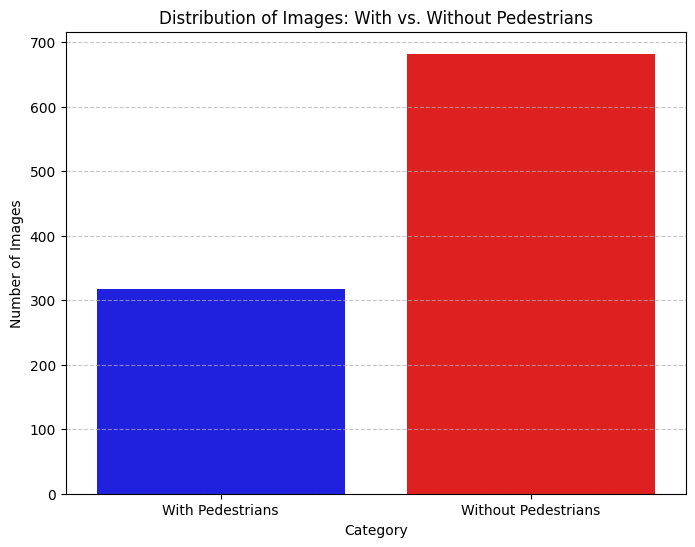

In [42]:
counts = [len(images_with_peds), len(images_without_peds)]
labels = ['With Pedestrians', 'Without Pedestrians']

fig = plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=counts, hue=labels, palette=['blue', 'red'], legend=False)
plt.title('Distribution of Images: With vs. Without Pedestrians')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Detecting pedestrians and collecting bounding box dimensions for 1000 images...


Collected 618 pedestrian bounding box dimensions.


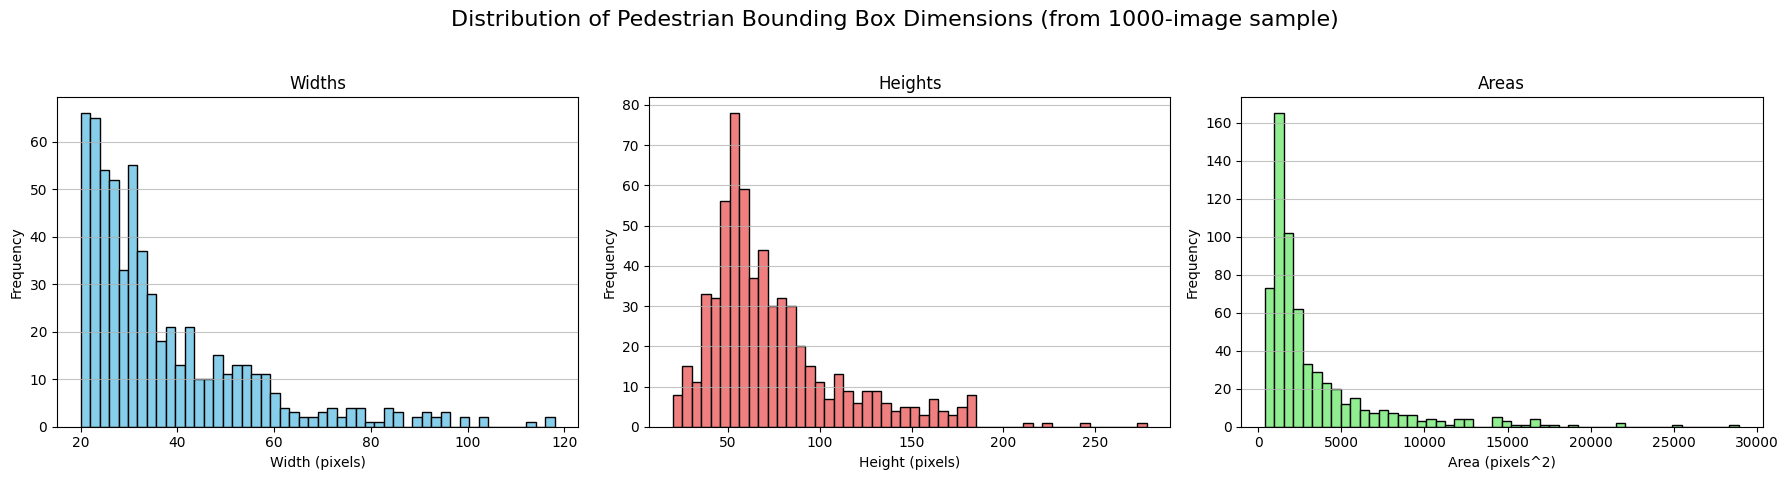

In [43]:
if 'visible_paths_sample' not in locals() or not visible_paths_sample or len(visible_paths_sample) != 1000:

    print(f"'visible_paths_sample' not found, empty, or not of size {sample_size}. Re-sampling...")
    # Assuming 'visible_paths' is defined from earlier cells
    visible_paths_sample = random.sample(visible_paths, sample_size)

all_pedestrian_widths = []
all_pedestrian_heights = []
all_pedestrian_areas = []

print(f"Detecting pedestrians and collecting bounding box dimensions for {len(visible_paths_sample)} images...")
for img_path in tqdm(visible_paths_sample, desc="Collecting dimensions"):
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Resize for detection (as done in detect_pedestrians_ensemble)
    det_h, det_w = 384, 640
    img_small = cv2.resize(img, (det_w, det_h))

    boxes = detect_pedestrians_ensemble(img_small)

    for box in boxes:
        # Box format: [x1, y1, x2, y2, conf]
        x1, y1, x2, y2 = box[0], box[1], box[2], box[3]
        width = x2 - x1
        height = y2 - y1
        area = width * height

        all_pedestrian_widths.append(width)
        all_pedestrian_heights.append(height)
        all_pedestrian_areas.append(area)

print(f"Collected {len(all_pedestrian_widths)} pedestrian bounding box dimensions.")

if all_pedestrian_widths and all_pedestrian_heights and all_pedestrian_areas:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Distribution of Pedestrian Bounding Box Dimensions (from 1000-image sample)', fontsize=16)

    # Histogram for Width
    axes[0].hist(all_pedestrian_widths, bins=50, color='skyblue', edgecolor='black')
    axes[0].set_title('Widths')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(axis='y', alpha=0.75)

    # Histogram for Height
    axes[1].hist(all_pedestrian_heights, bins=50, color='lightcoral', edgecolor='black')
    axes[1].set_title('Heights')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(axis='y', alpha=0.75)

    # Histogram for Area
    axes[2].hist(all_pedestrian_areas, bins=50, color='lightgreen', edgecolor='black')
    axes[2].set_title('Areas')
    axes[2].set_xlabel('Area (pixels^2)')
    axes[2].set_ylabel('Frequency')
    axes[2].grid(axis='y', alpha=0.75)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("No pedestrian bounding boxes were detected in the sample to create histograms.")

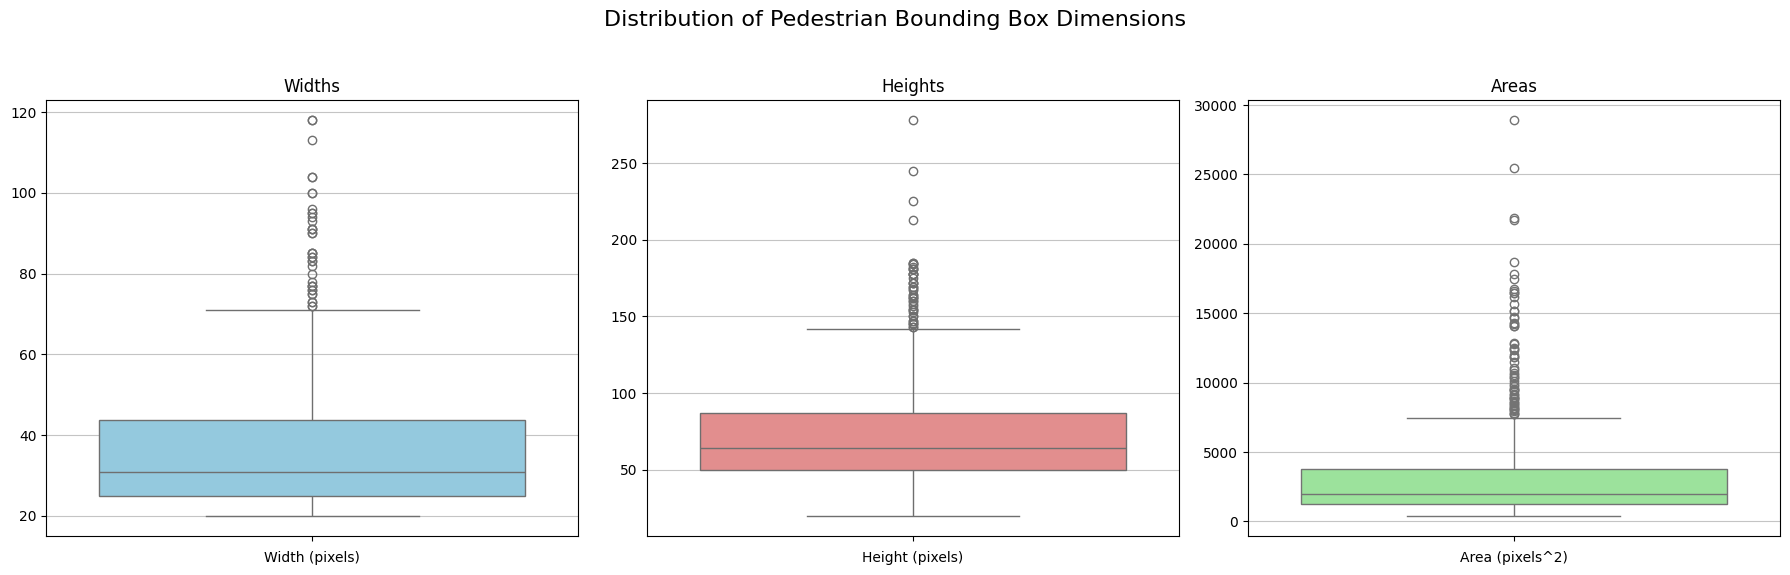

In [44]:
if all_pedestrian_widths and all_pedestrian_heights and all_pedestrian_areas:
    df_dims = pd.DataFrame({
        'Width': all_pedestrian_widths,
        'Height': all_pedestrian_heights,
        'Area': all_pedestrian_areas
    })

    # Create a single figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Adjust figsize as needed
    fig.suptitle('Distribution of Pedestrian Bounding Box Dimensions', fontsize=16)

    # Box Plot for Width
    sns.boxplot(y=df_dims['Width'], color='skyblue', ax=axes[0])
    axes[0].set_title('Widths')
    axes[0].set_xlabel('Width (pixels)') # Changed to xlabel since y is now the dimension
    axes[0].set_ylabel('') # Clear y-label for consistency, or set a general one in suptitle
    axes[0].grid(axis='y', alpha=0.75)

    # Box Plot for Height
    sns.boxplot(y=df_dims['Height'], color='lightcoral', ax=axes[1])
    axes[1].set_title('Heights')
    axes[1].set_xlabel('Height (pixels)') # Changed to xlabel
    axes[1].set_ylabel('')
    axes[1].grid(axis='y', alpha=0.75)

    # Box Plot for Area
    sns.boxplot(y=df_dims['Area'], color='lightgreen', ax=axes[2])
    axes[2].set_title('Areas')
    axes[2].set_xlabel('Area (pixels^2)') # Changed to xlabel
    axes[2].set_ylabel('')
    axes[2].grid(axis='y', alpha=0.75)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("Not enough data collected for bounding box dimensions to create box plots.")

In [45]:
if all_pedestrian_widths and all_pedestrian_heights and all_pedestrian_areas:
    mean_width = np.mean(all_pedestrian_widths)
    mean_height = np.mean(all_pedestrian_heights)
    mean_area = np.mean(all_pedestrian_areas)

    print(f"Mean Pedestrian Bounding Box Width: {mean_width:.2f} pixels")
    print(f"Mean Pedestrian Bounding Box Height: {mean_height:.2f} pixels")
    print(f"Mean Pedestrian Bounding Box Area: {mean_area:.2f} pixels^2")
else:
    print("No pedestrian bounding box data available to calculate mean dimensions.")

Mean Pedestrian Bounding Box Width: 36.97 pixels
Mean Pedestrian Bounding Box Height: 74.64 pixels
Mean Pedestrian Bounding Box Area: 3320.22 pixels^2


In [46]:
# Create a mapping from visible path to LWIR path
rgb_to_ir_map = {rgb_path.replace('/visible/', '/'): ir_path.replace('/lwir/', '/') for rgb_path, ir_path in zip(visible_paths, lwir_paths)}

# Filter for common keys (images present in both modalities)
common_keys = sorted(list(set(p.replace('/visible/', '/') for p in visible_paths).intersection(set(p.replace('/lwir/', '/') for p in lwir_paths))))

# Reconstruct the paired lists using only common keys
visible_paths_filtered = [os.path.join(os.path.dirname(key), 'visible', os.path.basename(key)) for key in common_keys]
lwir_paths_filtered = [os.path.join(os.path.dirname(key), 'lwir', os.path.basename(key)) for key in common_keys]

# Recreate the map from the filtered paths to ensure only paired images are used
rgb_to_ir_map_filtered = {rgb_path: ir_path for rgb_path, ir_path in zip(visible_paths_filtered, lwir_paths_filtered)}

print(f"Created a mapping of {len(rgb_to_ir_map_filtered)} paired image paths.")

Created a mapping of 50184 paired image paths.


In [47]:
def get_masked_background_and_features(rgb_image_path, ir_image_path, k=3):
    rgb_img = cv2.imread(rgb_image_path)
    ir_img = cv2.imread(ir_image_path, cv2.IMREAD_GRAYSCALE)

    if rgb_img is None or ir_img is None:
        return None, None, None, None, None

    original_h, original_w, _ = rgb_img.shape

    # Resize for detection
    det_h, det_w = 384, 640 # Consistent with previous detection cells
    rgb_small = cv2.resize(rgb_img, (det_w, det_h))

    # Detect pedestrians
    boxes = detect_pedestrians_ensemble(rgb_small)

    # Scale boxes back to original image dimensions
    scaled_boxes = []
    sx = original_w / det_w
    sy = original_h / det_h
    for box in boxes:
        x1, y1, x2, y2, conf = box
        scaled_boxes.append([
            int(x1 * sx),
            int(y1 * sy),
            int(x2 * sx),
            int(y2 * sy),
            conf
        ])

    # Create a mask for all detected pedestrians
    mask = np.ones(rgb_img.shape[:2], dtype=np.uint8) * 255 # White mask for background
    if scaled_boxes:
        for x1, y1, x2, y2, _ in scaled_boxes:
            # Ensure coordinates are within image bounds
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(original_w, x2)
            y2 = min(original_h, y2)
            cv2.rectangle(mask, (x1, y1), (x2, y2), 0, -1) # Black out pedestrian regions

    # Apply mask to get background
    rgb_background_masked = rgb_img.copy()
    ir_background_masked = ir_img.copy()

    # Create a 3-channel mask for RGB to handle cases where background should be black
    rgb_mask_3_channel = np.stack([mask, mask, mask], axis=-1)
    rgb_background_masked[rgb_mask_3_channel == 0] = 0 # Set masked areas to black

    ir_background_masked[mask == 0] = 0 # Set masked areas to black

    # Extract pixels for KMeans and IR statistics
    pixels_for_kmeans = rgb_background_masked.reshape(-1, 3)
    pixels_for_kmeans = pixels_for_kmeans[np.any(pixels_for_kmeans != 0, axis=1)] # Only non-black pixels

    ir_pixels = ir_background_masked.flatten()
    ir_pixels = ir_pixels[ir_pixels != 0] # Only non-black pixels

    dominant_colours = None
    if len(pixels_for_kmeans) > 0:
        kmeans = KMeans(n_clusters=min(k, len(pixels_for_kmeans)), random_state=0, n_init='auto')
        kmeans.fit(pixels_for_kmeans)
        dominant_colours = kmeans.cluster_centers_

    return rgb_background_masked, ir_background_masked, dominant_colours, ir_pixels, k

## Collecting background features from 1000 sample images

In [52]:
all_rgb_backgrounds_for_analysis = []
all_ir_pixels_data = []

print(f"Extracting background features from {len(training_data)} samples in training_data...")

# Iterate through training_data to extract rgb_bg_targets and ir_bg_targets
for sample_data in tqdm(training_data, desc="Extracting background features from training_data"):
    # training_data structure: (scene_context, rgb_bg_targets, ir_bg_targets, rgb, ir, all_boxes, rgb_path, ir_path)
    # We are interested in rgb_bg_targets (index 1) and ir_bg_targets (index 2)
    _, rgb_bg_targets_list, ir_bg_targets_list, _, _, _, _, _, _ = sample_data

    for rgb_patch in rgb_bg_targets_list:
        if rgb_patch is not None and rgb_patch.size > 0:
            all_rgb_backgrounds_for_analysis.append(rgb_patch)

    for ir_patch in ir_bg_targets_list:
        if ir_patch is not None and ir_patch.size > 0:
            all_ir_pixels_data.extend(ir_patch.flatten()) # Flatten and extend all IR pixels

print(f"Collected background features from {len(all_rgb_backgrounds_for_analysis)} RGB patches and {len(all_ir_pixels_data)} IR pixels.")

Extracting background features from 17205 samples in training_data...


Extracting background features from training_data: 100%|██████████| 17205/17205 [00:15<00:00, 1075.79it/s]

Collected background features from 34684 RGB patches and 288315842 IR pixels.


### 1. Dominant Colours in Background

In [54]:
# Aggregate all dominant colors and re-run KMeans for overall dominant colors
if all_dominant_colours_list:
    # Use the collected dominant colors or directly aggregate all non-zero pixels
    # For better representation, let's aggregate all non-zero RGB pixels from all backgrounds
    all_non_zero_rgb_pixels = np.vstack([bg[np.any(bg != 0, axis=2)] for bg in all_rgb_backgrounds_for_analysis if bg.size > 0])

    if len(all_non_zero_rgb_pixels) > 0:
        k = 5 # Number of overall dominant colors
        kmeans_overall = KMeans(n_clusters=min(k, len(all_non_zero_rgb_pixels)), random_state=0, n_init='auto')
        kmeans_overall.fit(all_non_zero_rgb_pixels)
        overall_dominant_colours = kmeans_overall.cluster_centers_

        print("### Overall Dominant Colours in Background")
        print("The overall dominant colors in the RGB background are:")
        for i, color in enumerate(overall_dominant_colours):
            print(f"Color {i+1}: RGB({color[0]:.2f}, {color[1]:.2f}, {color[2]:.2f})")

        plt.figure(figsize=(8, 2))
        for i, color in enumerate(overall_dominant_colours):
            plt.subplot(1, len(overall_dominant_colours), i + 1)
            plt.imshow([[color.astype(np.uint8)]])
            plt.axis("off")
        plt.suptitle("Overall Dominant Colors in Background")
        plt.show()
    else:
        print("No non-zero RGB pixels found in backgrounds to determine dominant colors.")
else:
    print("No dominant colors collected from the sample for background analysis.")

print("\n" + "-" * 50 + "\n")

NameError: name 'all_dominant_colours_list' is not defined

# Architecture

## Encoders

In [55]:
class MotionEncoder(nn.Module):

    def __init__(
        self,
        input_dim=6,
        hidden_dim=64,
        output_dim=128
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(inplace=True),

            nn.Linear(output_dim, output_dim)
        )

    def forward(self, motion):

        return self.encoder(motion)

In [60]:
def normalize_motion(
    motion,
    motion_mean,
    motion_std
):

    motion = np.asarray(
        motion,
        dtype=np.float32
    )

    return (
        motion - motion_mean
    ) / (
        motion_std + 1e-8
    )

# Unit Test Block

## Motion Testing

In [ ]:
def test_real_kaist_motion(train_pairs, sequence_dict=None, num_sequences=1):
    """
    Test frame-to-frame pedestrian motion using actual KAIST frames.

    Uses:
        - actual consecutive RGB frames
        - existing pedestrian detector
        - existing IoU function
        - existing motion feature function
    """

    print("=" * 70)
    print("REAL KAIST FRAME-TO-FRAME MOTION TEST (Using specific train_pairs)")
    print("=" * 70)

    # Use specific train_pairs for testing
    # The original loop and num_sequences logic are removed for this specific test case
    prev_pair = train_pairs[450]
    curr_pair = train_pairs[451]

    prev_rgb_path = prev_pair[0]
    curr_rgb_path = curr_pair[0]

    prev_img = cv2.imread(prev_rgb_path)
    curr_img = cv2.imread(curr_rgb_path)

    if prev_img is None or curr_img is None:
        print("Could not load frames.")
        return # Exit the function if frames cannot be loaded

    print(f"\nTesting with train_pairs[450] and train_pairs[451]:")
    print(f"Previous frame: {prev_rgb_path}")
    print(f"Current frame: {curr_rgb_path}")

    # Resize exactly as used by your detector pipeline
    prev_img_small = cv2.resize(
        prev_img,
        (640, 384)
    )

    curr_img_small = cv2.resize(
        curr_img,
        (640, 384)
    )

    # Detect pedestrians
    prev_boxes = detect_pedestrians_ensemble(
        prev_img_small
    )

    curr_boxes = detect_pedestrians_ensemble(
        curr_img_small
    )

    print(
        f"\nPrevious frame pedestrians: "
        f"{len(prev_boxes)}"
    )

    print(
        f"Current frame pedestrians: "
        f"{len(curr_boxes)}"
    )

    if len(prev_boxes) == 0 or len(curr_boxes) == 0:
        print(
            "Could not find pedestrians in both frames."
        )
        return # Exit if no pedestrians found

    # -------------------------------------------------
    # Match current pedestrians to previous pedestrians
    # using IoU
    # -------------------------------------------------

    matches = []

    for curr_idx, curr_box in enumerate(curr_boxes):

        best_iou = 0.0
        best_prev_idx = None

        for prev_idx, prev_box in enumerate(prev_boxes):

            iou = compute_iou(
                prev_box[:4],
                curr_box[:4]
            )

            if iou > best_iou:
                best_iou = iou
                best_prev_idx = prev_idx

        if best_prev_idx is not None:

            matches.append(
                (
                    best_prev_idx,
                    curr_idx,
                    best_iou
                )
            )

    # -------------------------------------------------
    # Print matches and motion
    # -------------------------------------------------

    valid_matches = 0

    for prev_idx, curr_idx, iou in matches:

        # Require reasonable overlap
        if iou < 0.3:
            continue

        prev_box = prev_boxes[prev_idx]
        curr_box = curr_boxes[curr_idx]

        motion = compute_motion_features(
            prev_box,
            curr_box
        )

        print("\n" + "-" * 60)

        print(
            f"Pedestrian match "
            f"(IoU = {iou:.3f})"
        )

        print(
            "Previous box:",
            np.round(prev_box, 2)
        )

        print(
            "Current box :",
            np.round(curr_box, 2)
        )

        print("\nMotion features:")

        print(
            f"dx           = {motion[0]:.3f}"
        )

        print(
            f"dy           = {motion[1]:.3f}"
        )

        print(
            f"dw           = {motion[2]:.3f}"
        )

        print(
            f"dh           = {motion[3]:.3f}"
        )

        print(
            f"scale change = {motion[4]:.5f}"
        )

        print(
            f"speed        = {motion[5]:.3f}"
        )

        valid_matches += 1

    print("\n" + "=" * 70)

    if valid_matches > 0:
        print(
            f"SUCCESS: Found {valid_matches} "
            f"valid frame-to-frame pedestrian match(es)."
        )
    else:
        print(
            "No reliable pedestrian matches found."
        )

    print("=" * 70)


In [ ]:
test_real_kaist_motion(
    train_pairs,
    sequence_dict,
    num_sequences=1
)

## Dataset Builder Test

In [ ]:
print("Number of training samples:", len(training_data))

sample = training_data[0]

print("\nNumber of fields:", len(sample))

for i, item in enumerate(sample):

    if isinstance(item, np.ndarray):

        print(
            f"{i}: ndarray "
            f"shape={item.shape} "
            f"dtype={item.dtype}"
        )

    elif isinstance(item, list):

        print(
            f"{i}: list "
            f"length={len(item)}"
        )

    else:

        print(
            f"{i}: {type(item)}"
        )


print("\nMotion features:")

for i, motion in enumerate(sample[1]):

    print(
        f"Pedestrian {i}:",
        motion
    )

## Encoder Tests

In [56]:
motion_encoder = MotionEncoder()

x = torch.randn(32, 6)

y = motion_encoder(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([32, 6])
Output shape: torch.Size([32, 128])


In [58]:
# with open("training_data_motion_aware_final.pkl", "rb") as f:
#     training_data = pickle.load(f)

print("Total samples:", len(training_data))
print("Sample length:", len(training_data[0]))

motion_features = training_data[0][6]

print("Motion feature type:", type(motion_features))
print("Number of pedestrians:", len(motion_features))

if len(motion_features) > 0:
    print("First motion vector:", motion_features[0])
    print("Motion vector length:", len(motion_features[0]))

Total samples: 17205
Sample length: 9
Motion feature type: <class 'list'>
Number of pedestrians: 1
First motion vector: [          0           0           0           0           0           0]
Motion vector length: 6


In [59]:
all_motion_vectors = []

for sample in training_data:

    motion_features = sample[6]

    for motion in motion_features:

        motion = np.asarray(
            motion,
            dtype=np.float32
        )

        if motion.shape == (6,):
            all_motion_vectors.append(motion)


all_motion_vectors = np.stack(
    all_motion_vectors,
    axis=0
)

print(
    "Total pedestrian motion vectors:",
    all_motion_vectors.shape[0]
)

print(
    "Motion matrix shape:",
    all_motion_vectors.shape
)


motion_mean = all_motion_vectors.mean(axis=0)

motion_std = all_motion_vectors.std(axis=0)


print("\nMotion mean:")
print(motion_mean)

print("\nMotion std:")
print(motion_std)


zero_motion_mask = np.all(
    all_motion_vectors == 0,
    axis=1
)

zero_motion_count = zero_motion_mask.sum()

zero_motion_percentage = (
    zero_motion_count /
    len(all_motion_vectors)
) * 100


print(
    "\nZero-motion vectors:",
    zero_motion_count
)

print(
    f"Zero-motion percentage: "
    f"{zero_motion_percentage:.2f}%"
)

Total pedestrian motion vectors: 34684
Motion matrix shape: (34684, 6)

Motion mean:
[    0.23754     0.36658     0.14623     0.62556   0.0083697      3.6802]

Motion std:
[     4.3214      3.8332      4.3648      7.4175    0.078654      4.4737]

Zero-motion vectors: 9518
Zero-motion percentage: 27.44%
